# Conditioning on the marginal gives spurious correlations


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import multivariate_hypergeom, spearmanr
from sklearn.metrics.pairwise import cosine_similarity

rng = np.random.default_rng(1426)


## Shared helper functions

In [2]:

def read_expr_csv(path):
    df = pd.read_csv(path)
    mat = df.iloc[:, 1:].to_numpy()
    rownames = df.iloc[:, 0].astype(str).to_list()
    colnames = df.columns[1:].astype(str).to_list()
    return pd.DataFrame(mat, index=rownames, columns=colnames)


def random_partition_counts(pooled_counts, n_first, rng=None):
    """
    Randomly partition a pooled count vector into two count vectors of sizes
    n_first and pooled_counts.sum() - n_first, without replacement.
    """
    pooled_counts = np.asarray(pooled_counts, dtype=int)
    total = int(pooled_counts.sum())

    if not (0 <= n_first <= total):
        raise ValueError("`n_first` must be between 0 and sum(pooled_counts).")

    if rng is None:
        rng = np.random.default_rng()

    first_counts = multivariate_hypergeom.rvs(
        m=pooled_counts,
        n=n_first,
        random_state=rng,
    )
    second_counts = pooled_counts - first_counts
    return np.column_stack([first_counts, second_counts])


def lognorm(x, scale=1e4):
    x = np.asarray(x, dtype=float)
    total = x.sum()
    if total == 0:
        return np.zeros_like(x, dtype=float)
    return np.log1p((x / total) * scale)


def cosine_np(x, y):
    x = np.asarray(x, dtype=float).ravel()
    y = np.asarray(y, dtype=float).ravel()
    nx = np.linalg.norm(x)
    ny = np.linalg.norm(y)
    if nx == 0.0 or ny == 0.0:
        return np.nan
    return float(np.dot(x, y) / (nx * ny))


def cosine(x, y):
    return cosine_similarity(np.asarray(x).reshape(1, -1), np.asarray(y).reshape(1, -1))[0, 0]


def rank_transform(x):
    return pd.Series(x).rank().to_numpy()


def chi2_dist(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x = x / x.sum() if x.sum() > 0 else x
    y = y / y.sum() if y.sum() > 0 else y
    return np.sum((x - y) ** 2 / (x + y + 1e-8))


def kl_div(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x = x / x.sum() if x.sum() > 0 else x
    y = y / y.sum() if y.sum() > 0 else y
    return np.sum(x * np.log((x + 1e-8) / (y + 1e-8)))


def sim(x1, x2, trsf=np.log1p, n_sim=1000, bins=50, rng=None):
    """
    Compare observed correlation to the null distribution obtained by randomly
    repartitioning pooled counts.
    """
    x1 = np.asarray(x1, dtype=int)
    x2 = np.asarray(x2, dtype=int)
    pooled = x1 + x2
    obs_cor = np.corrcoef(trsf(x1), trsf(x2))[0, 1]

    if rng is None:
        rng = np.random.default_rng()

    simcor = np.empty(n_sim, dtype=float)
    for i in range(n_sim):
        rcc = random_partition_counts(pooled, int(x1.sum()), rng=rng)
        simcor[i] = np.corrcoef(trsf(rcc[:, 0]), trsf(rcc[:, 1]))[0, 1]

    fig, ax = plt.subplots(figsize=(4, 3))
    ax.hist(simcor, bins=bins)
    ax.axvline(obs_cor, color="blue", linewidth=2)
    ax.set_xlabel("correlation")
    ax.set_ylabel("count")
    ax.set_title("Null distribution vs observed")
    plt.tight_layout()

    return {
        "observed_correlation": obs_cor,
        "null_mean": float(np.mean(simcor)),
        "null_sd": float(np.std(simcor, ddof=1)),
        "simulated_correlations": simcor,
        "figure": fig,
    }


def cellwise_cosine_after_global_gene_removal(ec, eb, fractions_remove):
    gene_abundance = np.asarray(ec.sum(axis=0) + eb.sum(axis=0))
    order = np.argsort(gene_abundance)[::-1]

    ec_np = ec.to_numpy() if hasattr(ec, "to_numpy") else np.asarray(ec)
    eb_np = eb.to_numpy() if hasattr(eb, "to_numpy") else np.asarray(eb)
    n_genes = ec_np.shape[1]

    results = []
    for frac in fractions_remove:
        k = int(np.floor(frac * n_genes))
        keep = np.ones(n_genes, dtype=bool)
        if k > 0:
            keep[order[:k]] = False

        cos_vals = np.array([
            cosine_np(lognorm(ec_np[i, keep]), lognorm(eb_np[i, keep]))
            for i in range(ec_np.shape[0])
        ])
        results.append({
            "fraction_top_genes_removed": frac,
            "mean_cosine": np.nanmean(cos_vals),
            "median_cosine": np.nanmedian(cos_vals),
        })
    return pd.DataFrame(results)


def cellwise_drop_after_percentile_removal(ec, eb, percentiles):
    ec_np = ec.to_numpy() if hasattr(ec, "to_numpy") else np.asarray(ec)
    eb_np = eb.to_numpy() if hasattr(eb, "to_numpy") else np.asarray(eb)

    baseline = []
    for i in range(ec_np.shape[0]):
        x = ec_np[i]
        y = eb_np[i]
        pooled = x + y
        keep = pooled > 0
        if keep.sum() == 0 or x[keep].sum() == 0 or y[keep].sum() == 0:
            baseline.append(np.nan)
        else:
            baseline.append(cosine_np(lognorm(x[keep]), lognorm(y[keep])))
    baseline = np.array(baseline)

    drop_summary = []
    for p in percentiles:
        new_cos = []

        for i in range(ec_np.shape[0]):
            x = ec_np[i].copy()
            y = eb_np[i].copy()

            pooled = x + y
            nonzero = pooled > 0
            x = x[nonzero]
            y = y[nonzero]
            pooled = pooled[nonzero]

            if len(pooled) == 0:
                new_cos.append(np.nan)
                continue

            thresh = np.percentile(pooled, p)
            keep = pooled <= thresh

            if keep.sum() == 0:
                new_cos.append(np.nan)
                continue

            x_keep = x[keep]
            y_keep = y[keep]

            if x_keep.sum() == 0 or y_keep.sum() == 0:
                new_cos.append(np.nan)
                continue

            new_cos.append(cosine_np(lognorm(x_keep), lognorm(y_keep)))

        new_cos = np.array(new_cos)
        delta = baseline - new_cos

        drop_summary.append({
            "percentile_cutoff": p,
            "mean_drop": np.nanmean(delta),
            "median_drop": np.nanmedian(delta),
        })

    return pd.DataFrame(drop_summary)


## Example data (optional)


{'observed_correlation': np.float64(0.4201755931408838), 'null_mean': 0.4514148642884173, 'null_sd': 0.05160349204989754}


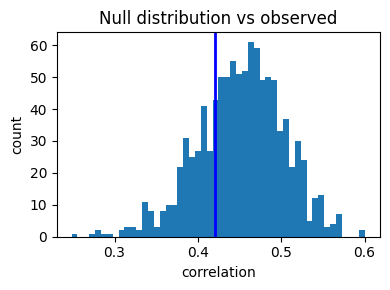

In [3]:
def read_expr_csv(path):
    df = pd.read_csv(path)
    mat = df.iloc[:, 1:].to_numpy()
    rownames = df.iloc[:, 0].astype(str).to_list()
    colnames = df.columns[1:].astype(str).to_list()
    return pd.DataFrame(mat, index=rownames, columns=colnames)


center_path = Path("expr_center.csv")
border_path = Path("expr_border.csv")

if center_path.exists() and border_path.exists():
    ec = read_expr_csv(center_path)
    eb = read_expr_csv(border_path)
    assert ec.shape == eb.shape
    assert list(ec.index) == list(eb.index)
    assert list(ec.columns) == list(eb.columns)

    j = 199  # R's j = 200
    res_real = sim(ec.iloc[j].to_numpy(), eb.iloc[j].to_numpy(), rng=rng)
    print({k: v for k, v in res_real.items() if k not in {"simulated_correlations", "figure"}})
    plt.show()
else:
    print("expr_center.csv / expr_border.csv not found. Skip this section or place the files next to the notebook.")

## Random data


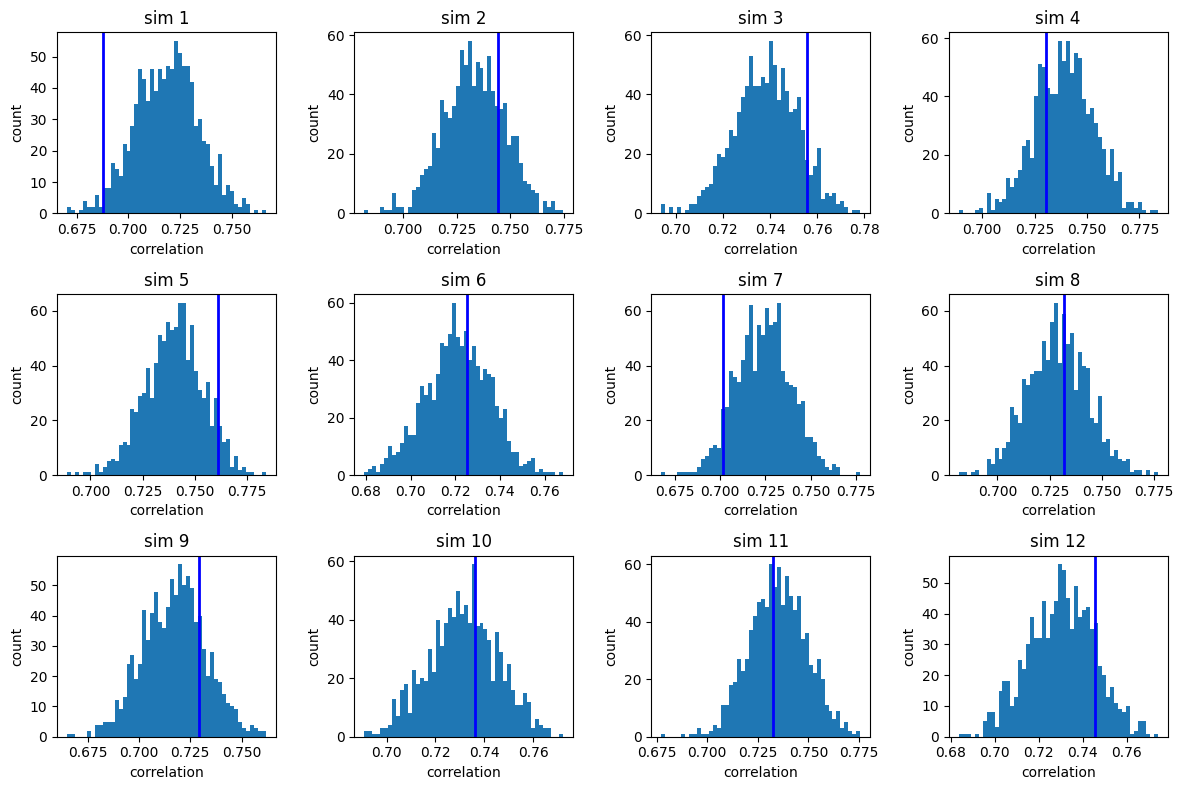

In [4]:
fig, axes = plt.subplots(3, 4, figsize=(12, 8))
axes = axes.ravel()

for i, ax in enumerate(axes):
    lam = np.exp(rng.normal(loc=1, scale=1, size=500))
    x1 = rng.poisson(lam)
    x2 = rng.poisson(lam)

    pooled = x1 + x2
    obs_cor = np.corrcoef(np.log1p(x1), np.log1p(x2))[0, 1]

    simcor = np.empty(1000, dtype=float)
    for b in range(1000):
        rcc = random_partition_counts(pooled, int(x1.sum()), rng=rng)
        simcor[b] = np.corrcoef(np.log1p(rcc[:, 0]), np.log1p(rcc[:, 1]))[0, 1]

    ax.hist(simcor, bins=50)
    ax.axvline(obs_cor, color="blue", linewidth=2)
    ax.set_title(f"sim {i+1}")
    ax.set_xlabel("correlation")
    ax.set_ylabel("count")

plt.tight_layout()
plt.show()

I think the simulation confirms what the null is supposed to encode, namely that if center and border are just two samples from the same underlying expression composition, they will already show substantial similarity due to shared gene-abundance structure. So I do not see that as a problem with the null itself. The more relevant question seems to be whether cosine similarity is sufficiently sensitive to the kinds of deviations we want to detect, e.g. contamination-like shifts at the border.

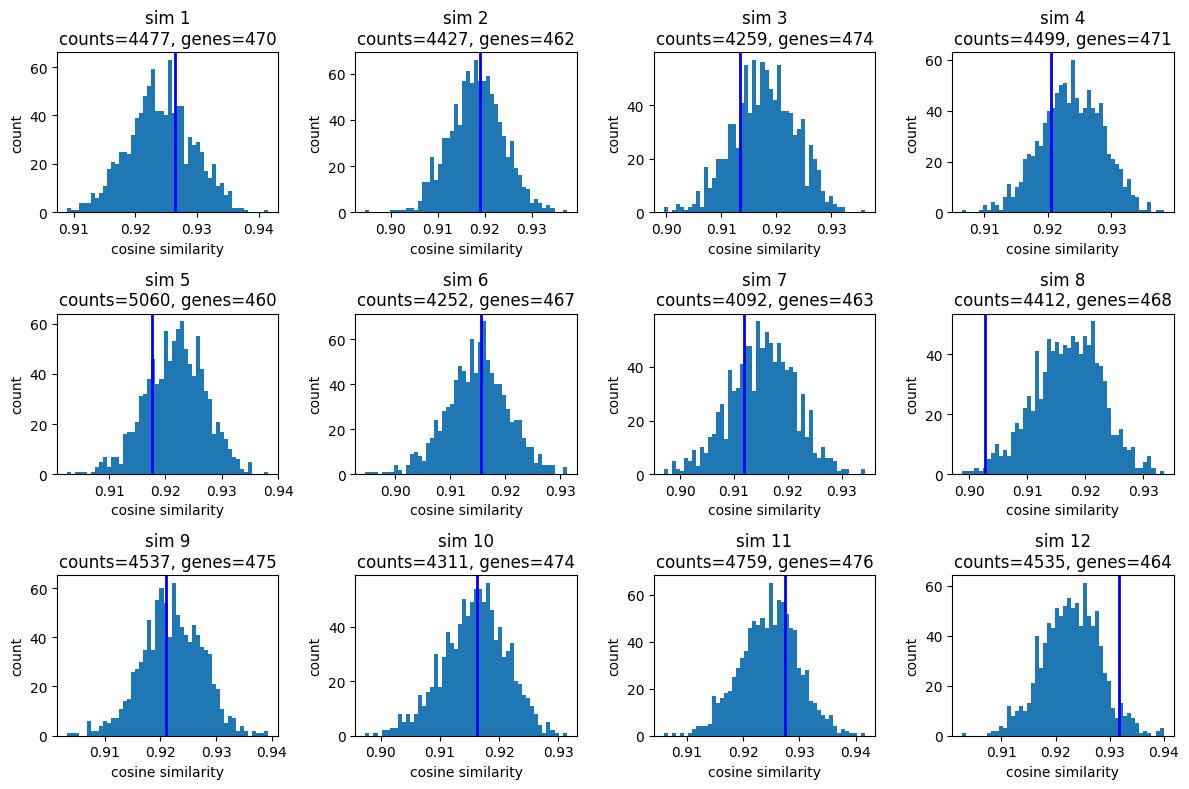

In [5]:
fig, axes = plt.subplots(3, 4, figsize=(12, 8))
axes = axes.ravel()

min_genes = 5
min_transcripts = 10
scale = 1e4
n_sim = 1000

for i, ax in enumerate(axes):
    lam = np.exp(rng.normal(loc=1, scale=1, size=500))
    x1_raw = rng.poisson(lam)
    x2_raw = rng.poisson(lam)

    # Same masking as in your approach:
    # keep genes nonzero in at least one of the two profiles
    mask = (x1_raw + x2_raw) > 0
    x1_raw = x1_raw[mask]
    x2_raw = x2_raw[mask]

    n_genes_used = int(mask.sum())
    n_x1 = int(x1_raw.sum())
    n_x2 = int(x2_raw.sum())

    if n_genes_used < min_genes or n_x1 < min_transcripts or n_x2 < min_transcripts:
        ax.text(0.5, 0.5, "filtered", ha="center", va="center")
        ax.set_axis_off()
        continue

    # observed cosine similarity, same normalization as in your approach
    x1 = np.log1p((x1_raw / n_x1) * scale)
    x2 = np.log1p((x2_raw / n_x2) * scale)
    obs_cos = cosine_np(x1, x2)

    # null: random partition of pooled counts with fixed observed totals
    pooled = x1_raw + x2_raw
    simcos = np.empty(n_sim, dtype=float)

    for b in range(n_sim):
        rcc = random_partition_counts(pooled, n_x1, rng=rng)
        x1_null_raw = rcc[:, 0]
        x2_null_raw = rcc[:, 1]

        x1_null = np.log1p((x1_null_raw / x1_null_raw.sum()) * scale)
        x2_null = np.log1p((x2_null_raw / x2_null_raw.sum()) * scale)

        simcos[b] = cosine_np(x1_null, x2_null)

    ax.hist(simcos, bins=50)
    ax.axvline(obs_cos, color="blue", linewidth=2)
    ax.set_title(f"sim {i+1}\ncounts={n_x1+n_x2}, genes={n_genes_used}")
    ax.set_xlabel("cosine similarity")
    ax.set_ylabel("count")

plt.tight_layout()
plt.show()

## Compare simulation against real data

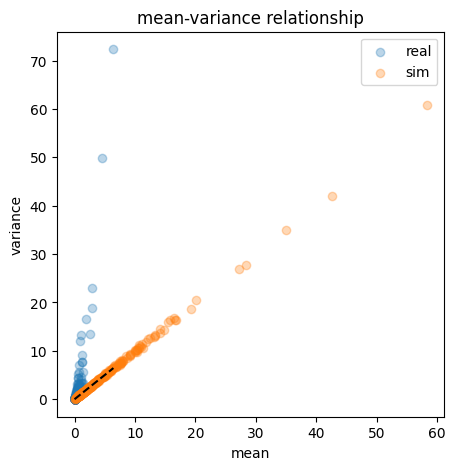

In [6]:
# real data
real = np.vstack([ec, eb])
gene_means_real = real.mean(axis=0)
gene_vars_real = real.var(axis=0)

# simulated data
rng = np.random.default_rng(0)
lam = np.exp(rng.normal(loc=1, scale=1, size=real.shape[1]))
sim = rng.poisson(lam, size=(real.shape[0], real.shape[1]))
gene_means_sim = sim.mean(axis=0)
gene_vars_sim = sim.var(axis=0)

plt.figure(figsize=(5,5))
plt.scatter(gene_means_real, gene_vars_real, alpha=0.3, label="real")
plt.scatter(gene_means_sim, gene_vars_sim, alpha=0.3, label="sim")
plt.plot([0, max(gene_means_real)], [0, max(gene_means_real)], 'k--')
plt.xlabel("mean")
plt.ylabel("variance")
plt.legend()
plt.title("mean-variance relationship")
plt.show()

In [7]:
real_zero_frac = (real == 0).mean()
sim_zero_frac = (sim == 0).mean()

print("Zero fraction (real):", real_zero_frac)
print("Zero fraction (sim):", sim_zero_frac)

Zero fraction (real): 0.8670132908984549
Zero fraction (sim): 0.16436492904566521


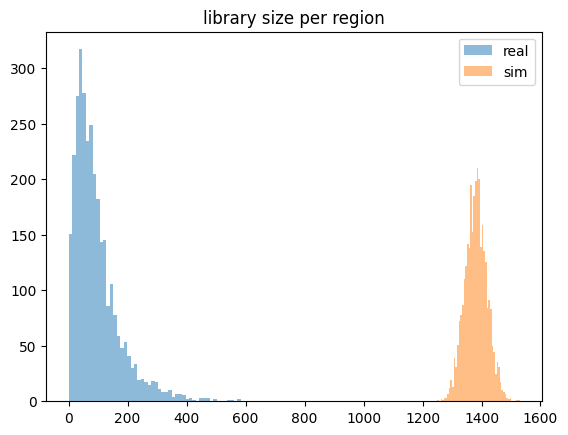

In [8]:
real_lib = real.sum(axis=1)
sim_lib = sim.sum(axis=1)

plt.hist(real_lib, bins=50, alpha=0.5, label="real")
plt.hist(sim_lib, bins=50, alpha=0.5, label="sim")
plt.legend()
plt.title("library size per region")
plt.show()

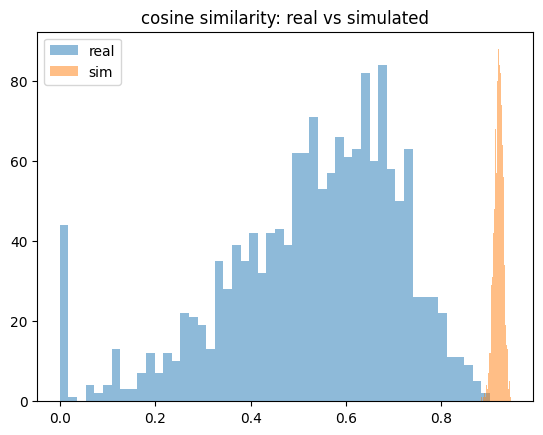

In [9]:
# real cosine similarities (center vs border per cell)
cos_real = [
    cosine(np.log1p(ec.iloc[i, :]), np.log1p(eb.iloc[i, :]))
    for i in range(ec.shape[0])
]

# simulated cosine (independent x1/x2)
cos_sim = []
for i in range(ec.shape[0]):
    lam = np.exp(rng.normal(loc=1, scale=1, size=ec.shape[1]))
    x1 = rng.poisson(lam)
    x2 = rng.poisson(lam)
    cos_sim.append(cosine(np.log1p(x1), np.log1p(x2)))

plt.hist(cos_real, bins=50, alpha=0.5, label="real")
plt.hist(cos_sim, bins=50, alpha=0.5, label="sim")
plt.legend()
plt.title("cosine similarity: real vs simulated")
plt.show()

## Alternative approaches

### Baseline cosine similarity

In [10]:
cos_raw = np.array([
    cosine(lognorm(ec.iloc[i, :].to_numpy()), lognorm(eb.iloc[i, :].to_numpy()))
    for i in range(ec.shape[0])
])

### Empirical null (LOESS-style correction)
similarity relative to count-matched expectation

In [11]:
counts = np.asarray(ec.sum(axis=1) + eb.sum(axis=1))
cos_raw = np.asarray(cos_raw)

bins = pd.qcut(counts, q=20, duplicates="drop")
mean_per_bin = pd.Series(cos_raw).groupby(bins).transform("mean").to_numpy()

cos_empirical_residual = cos_raw - mean_per_bin

/tmp/ipykernel_2344677/2440908066.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_per_bin = pd.Series(cos_raw).groupby(bins).transform("mean").to_numpy()


### Rank-based similarity (less sensitive to abundance)
similarity of gene ordering - removes global gene-abundance scale

In [12]:
cos_rank = np.array([
    cosine(rank_transform(ec.iloc[i,:].to_numpy()), rank_transform(eb.iloc[i,:].to_numpy()))
    for i in range(ec.shape[0])
])

### Gene-centered profiles (remove global abundance)
now similarity reflects deviation from expected gene abundance

In [13]:
# compute global gene means
global_mean = np.mean(np.vstack([ec, eb]), axis=0)

def centered(x):
    return lognorm(x) - lognorm(global_mean)

cos_centered = np.array([
    cosine(centered(ec.iloc[i, :].to_numpy()), centered(eb.iloc[i, :].to_numpy()))
    for i in range(ec.shape[0])
])

### Chi-square style distance (composition difference)
compositional distance

In [14]:
chi2_vals = np.array([
    chi2_dist(ec.iloc[i, :].to_numpy(), eb.iloc[i, :].to_numpy())
    for i in range(ec.shape[0])
])

### KL divergence (another alternative)
divergence between expression distributions

In [15]:
kl_vals = np.array([
    kl_div(ec.iloc[i, :].to_numpy(), eb.iloc[i, :].to_numpy())
    for i in range(ec.shape[0])
])

In [16]:
df = pd.DataFrame({
    "counts": np.asarray(counts),
    "cos_raw": np.asarray(cos_raw),
    "cos_empirical_residual": np.asarray(cos_empirical_residual),
    "cos_rank": np.asarray(cos_rank),
    "cos_centered": np.asarray(cos_centered),
    "chi2": np.asarray(chi2_vals),
    "kl": np.asarray(kl_vals),
})

# correlation with counts (key diagnostic)
for col in df.columns[1:]:
    r, _ = spearmanr(df[col], df["counts"])
    print(col, "Spearman with counts:", round(r, 3))

cos_raw Spearman with counts: 0.8
cos_empirical_residual Spearman with counts: 0.028
cos_rank Spearman with counts: -0.678
cos_centered Spearman with counts: -0.523
chi2 Spearman with counts: -0.741
kl Spearman with counts: -0.688


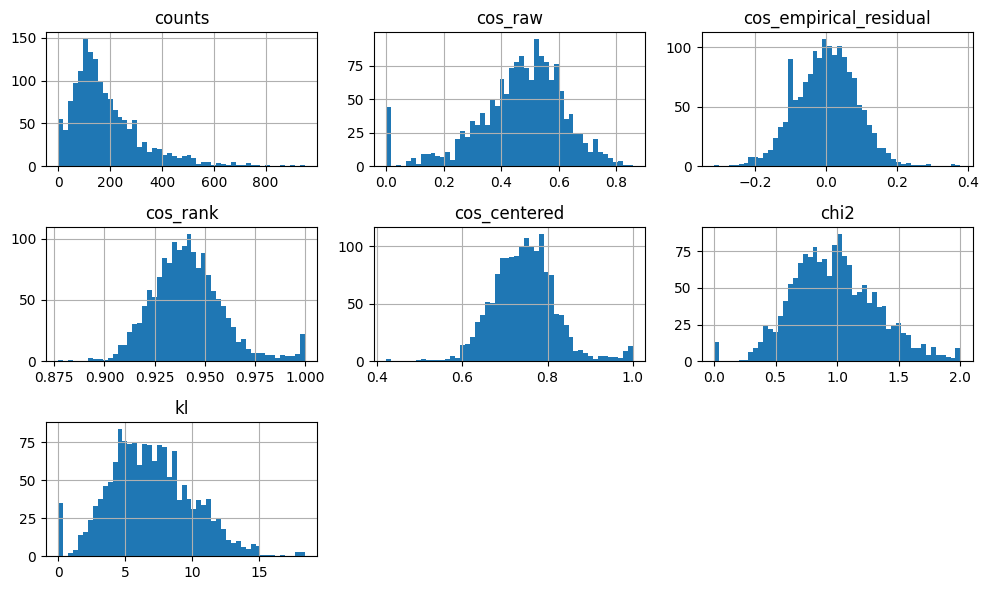

In [17]:
df.hist(figsize=(10,6), bins=50)
plt.tight_layout()
plt.show()

## Gene abundance driving similarity?

global drop in similarity after excluding globally most abundant genes

In [18]:
fractions_remove = [0.0, 0.01, 0.05, 0.1, 0.2]
results = cellwise_cosine_after_global_gene_removal(ec, eb, fractions_remove)
results


,fraction_top_genes_removed,mean_cosine,median_cosine
0,0.00,0.476380,0.488581
1,0.01,0.443170,0.450988
2,0.05,0.391558,0.392358
3,0.10,0.355425,0.358303
4,0.20,0.308291,0.306093


per cell drop in similarity after removing most abundant genes per cell

In [25]:
percentiles = np.arange(10, 100, 5).tolist()
df_drop = cellwise_drop_after_percentile_removal(ec, eb, percentiles)
df_drop


,percentile_cutoff,mean_drop,median_drop
0,10,0.476557,0.488639
1,15,0.476557,0.488639
2,20,0.476557,0.488639
3,25,0.476557,0.488639
4,30,0.474562,0.487293
5,35,0.469061,0.480805
6,40,0.453215,0.467638
7,45,0.426902,0.441324
8,50,0.387360,0.397540
9,55,0.349339,0.353158


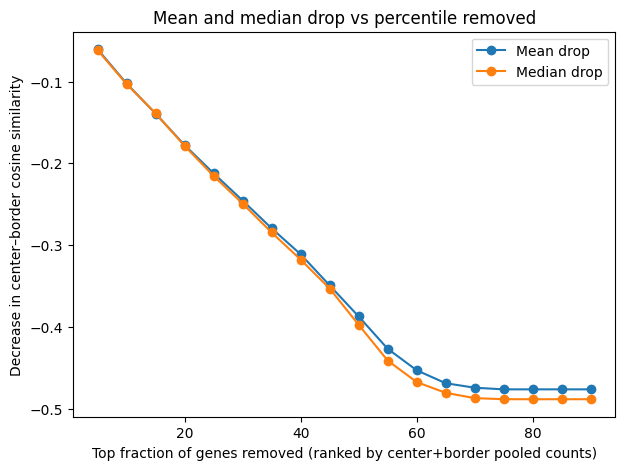

In [27]:
df = pd.DataFrame(df_drop)

plt.figure(figsize=(7, 5))
plt.plot(100-df["percentile_cutoff"], -df["mean_drop"], marker="o", label="Mean drop")
plt.plot(100-df["percentile_cutoff"], -df["median_drop"], marker="o", label="Median drop")
plt.xlabel("Top fraction of genes removed (ranked by center+border pooled counts)")
plt.ylabel("Decrease in center–border cosine similarity")
plt.title("Mean and median drop vs percentile removed")
plt.legend()
plt.show()

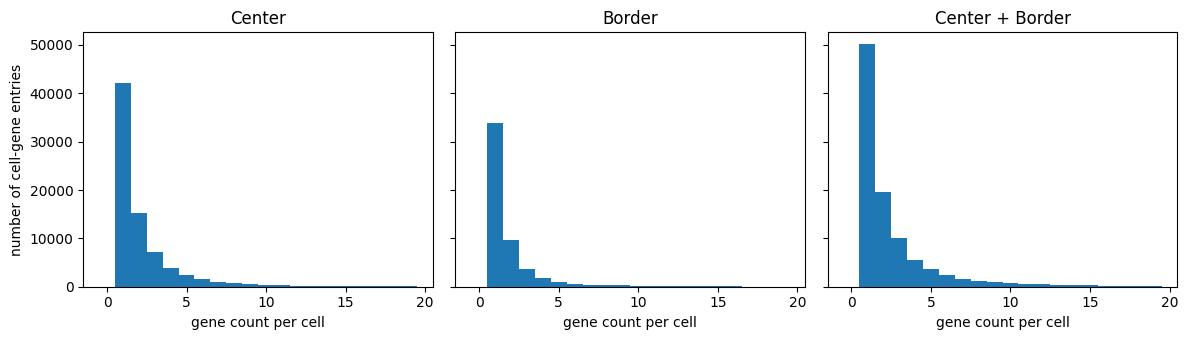

In [22]:
ec_np = ec.to_numpy() if hasattr(ec, "to_numpy") else np.asarray(ec)
eb_np = eb.to_numpy() if hasattr(eb, "to_numpy") else np.asarray(eb)

# flatten all cell-gene counts
center_counts = ec_np[ec_np > 0].ravel()
border_counts = eb_np[eb_np > 0].ravel()
pooled_counts = (ec_np + eb_np)[(ec_np + eb_np) > 0].ravel()

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)

axes[0].hist(center_counts, bins=np.arange(0, 21) - 0.5)
axes[0].set_title("Center")
axes[0].set_xlabel("gene count per cell")
axes[0].set_ylabel("number of cell-gene entries")

axes[1].hist(border_counts, bins=np.arange(0, 21) - 0.5)
axes[1].set_title("Border")
axes[1].set_xlabel("gene count per cell")

axes[2].hist(pooled_counts, bins=np.arange(0, 21) - 0.5)
axes[2].set_title("Center + Border")
axes[2].set_xlabel("gene count per cell")

plt.tight_layout()
plt.show()
